In [1]:
import os
import mne
# import PyQt6
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold

# from mne_features.univariate import compute_higuchi_fd

# %matplotlib qt

In [2]:
folders = [x for x in os.listdir('OCD/') if os.path.isdir('OCD/' + x)]
fldr2label = {folders[i]: i for i in range(len(folders))}
fldr2label

{'anxiety_ADD (47)': 0,
 'anxiety_AFD (18)': 1,
 'anxiety_general_AD (16)': 2,
 'bipolar_BPD_1(26)': 3,
 'bipolar_BPD_2(25)': 4,
 'controls (157)': 5,
 'Cyclothymia(10)': 6,
 'depression_mild (29)': 7,
 'depression_moderade (47)': 8,
 'depression_severe (32)': 9,
 'personality_disorder (56)': 10,
 'stress_eating_disorder (14)': 11,
 'stress_neurasthenia (7)': 12,
 'stress_Somatoform_disorder (12)': 13,
 'stress_Stress_disorder (24)': 14}

In [3]:
label2class = {
    0: 0, 1: 0, 2: 0, # anxiety
    3: 1, 4: 1, 6: 1, # bipolar
    5: 2, # control
    7: 3, 8: 3, 9: 3, # depression
    10: 4, # personality disorder,
    11: 5, 12: 5, 13: 5, 14: 5# stress
}

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress'}
name2class = {v: k for k, v in class2name.items()}

In [4]:
og_files = []
zg_files = []
og_labels = []
zg_labels = []
for fldr in folders:
    pth =  'OCD/' + fldr
    og_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('og.' in x.lower() or 'ог.' in x.lower() or 'eo.' in x.lower() or '_eo' in x.lower())]
    zg_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('zg.' in x.lower() or 'зг.' in x.lower() or 'ec.' in x.lower() or 'fon.' in x.lower() or '_ec' in x.lower() or 'eс.' in x.lower())]
    left = [x for x in os.listdir(pth) if x not in og_pths and x not in zg_pths]
    if len(left) > 0:
        print(pth, left)
    for f in og_pths:
        og_files.append(pth + '/' + f)
        og_labels.append(fldr2label[fldr])
    for f in zg_pths:
        zg_files.append(pth + '/' + f)
        zg_labels.append(fldr2label[fldr])

print(f'Number of files for open eyes: {len(og_files)}')
print(f'Number of files for closed eyes: {len(zg_files)}')

# ensured that og_files[i] is the pair for zg_files[i]

Number of files for open eyes: 518
Number of files for closed eyes: 518


In [5]:
short_recordings = []
for i in tqdm(range(len(og_files))):
    og_file = og_files[i]
    zg_file = zg_files[i]
    try:
        og_sample = mne.io.read_raw_edf(og_file, verbose=False)
        og_len = 1.0 * len(og_sample) / og_sample.info['sfreq']
        zg_sample = mne.io.read_raw_edf(zg_file, verbose=False)
        zg_len = 1.0 * len(zg_sample) / zg_sample.info['sfreq']
        if zg_len < 20 or og_len < 20:
            short_recordings.append(i)
    except Exception as e:
        print(f, e)

og_files = [x for i, x in enumerate(og_files) if i not in short_recordings]
zg_files = [x for i, x in enumerate(zg_files) if i not in short_recordings]
og_labels = [x for i, x in enumerate(og_labels) if i not in short_recordings]
zg_labels = [x for i, x in enumerate(zg_labels) if i not in short_recordings]

og_no_stress = [x for i, x in enumerate(og_files) if label2class[og_labels[i]] != 5]
zg_no_stress = [x for i, x in enumerate(zg_files) if label2class[zg_labels[i]] != 5]
og_labels_no_stress = [x for i, x in enumerate(og_labels) if label2class[og_labels[i]] != 5]
zg_labels_no_stress = [x for i, x in enumerate(zg_labels) if label2class[zg_labels[i]] != 5]

  0%|          | 0/518 [00:00<?, ?it/s]

МОГУТИНА ВВ_31_F43-0_ЗГ.EDF could not convert string to float: '        '
МОГУТИНА ВВ_31_F43-0_ЗГ.EDF could not convert string to float: '        '


In [6]:
Counter([label2class[x] for x in zg_labels])

Counter({2: 157, 3: 102, 0: 80, 1: 59, 5: 53, 4: 52})

# Calculate features

In [7]:
def compute_features(data, s_freq=250, pairs=[], n_channels=19):
    freq_bands = np.array([1, 4, 8, 13, 30])

    psd, freqs = mne.time_frequency.psd_array_welch(data, sfreq=s_freq, fmin=1, fmax=30, n_fft=512, n_per_seg=s_freq, window='hann', average=None, verbose=False)

    # compute ES and DE
    differential_entropy = np.zeros((psd.shape[0], len(freq_bands) - 1, psd.shape[2]))
    energy_spectrum = np.zeros((psd.shape[0], len(freq_bands) - 1, psd.shape[2]))

    for i in range(n_channels):
        for j in range(len(freq_bands) - 1):
            band_indices = np.where((freqs >= freq_bands[j]) & (freqs < freq_bands[j+1]))[0]
            if len(band_indices) > 0:
                band_psd = psd[i, band_indices]
                band_variance = np.mean(band_psd, axis=0)
                differential_entropy[i, j] = 0.5 * np.log(2 * np.pi * np.e * band_variance)
                energy_spectrum[i, j] = band_variance
    # compute asymmetry features
    left = differential_entropy[[x[0] for x in pairs]]
    right = differential_entropy[[x[1] for x in pairs]]
    dasm = left - right
    rasm = left / right
    return energy_spectrum, differential_entropy, dasm, rasm

In [10]:
# calculate features for the first 20s of each recording
n_channels = 19

cleaned_labels_zg = []
es_features_zg = []
de_features_zg = []
dasm_features_zg = []
rasm_features_zg = []

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    try:
        path = zg_files[i]
        if any([x in path for x in to_skip]):
            continue
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            continue

        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        channels = sample.ch_names
        to_drop = channels[19:]

        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            continue

        s_freq = int(sample.info['sfreq'])
        data = sample.get_data()[new_idx, :int(20 * s_freq)]

        es, de, dasm, rasm = compute_features(data, s_freq, idx_pairs)

        # print(np.array(es).shape)
        # print(np.array(de).shape)
        # print(np.array(dasm).shape)
        # print(np.array(rasm).shape)
        # break

        es_features_zg.append(es)
        de_features_zg.append(de)
        dasm_features_zg.append(dasm)
        rasm_features_zg.append(rasm)
        cleaned_labels_zg.append(zg_labels[i])
    except Exception as e:
        print(e)
        print(path)

  0%|          | 0/503 [00:00<?, ?it/s]

In [13]:
# calculate features for the first 20s of each recording
n_channels = 19

cleaned_labels_og = []
es_features_og = []
de_features_og = []
dasm_features_og = []
rasm_features_og = []

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in range(len(og_files)):
    try:
        path = og_files[i]
        if any([x in path for x in to_skip]):
            continue
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            continue

        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        channels = sample.ch_names
        to_drop = channels[19:]
        sample.drop_channels(to_drop)

        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            print(f'skipped {path}')
            continue

        s_freq = int(sample.info['sfreq'])
        data = sample.get_data()[new_idx, :int(20 * s_freq)]

        es, de, dasm, rasm = compute_features(data, s_freq, idx_pairs)
        es_features_og.append(es)
        de_features_og.append(de)
        dasm_features_og.append(dasm)
        rasm_features_og.append(rasm)
        cleaned_labels_og.append(og_labels[i])
    except Exception as e:
        print(e)
        print(path)

In [11]:
# es_features_og = np.array(es_features_og)
# de_features_og = np.array(de_features_og)
# dasm_features_og = np.array(dasm_features_og)
# rasm_features_og = np.array(rasm_features_og)
es_features_zg = np.array(es_features_zg)
de_features_zg = np.array(de_features_zg)
dasm_features_zg = np.array(dasm_features_zg)
rasm_features_zg = np.array(rasm_features_zg)

# cleaned_labels_og = np.array(cleaned_labels_og)
cleaned_labels_zg = np.array(cleaned_labels_zg)

# Closed eyes

In [14]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate((de_features_zg[train].reshape(-1, 19 * 4 * 20), dasm_features_zg[train].reshape(-1, 8 * 4 * 20), rasm_features_zg[train].reshape(-1, 8 * 4 * 20)), axis=1)
    X_test = np.concatenate((de_features_zg[test].reshape(-1, 19 * 4 * 20), dasm_features_zg[test].reshape(-1, 8 * 4 * 20), rasm_features_zg[test].reshape(-1, 8 * 4 * 20)), axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.34986472066493973, std: 0.05503257576741287
avg micro-f1: 0.4085454545454545


In [15]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = de_features_zg[train].reshape(-1, 19 * 4 * 20)
    X_test = de_features_zg[test].reshape(-1, 19 * 4 * 20)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.37205797071463265, std: 0.05774746378114341
avg micro-f1: 0.43466666666666665


In [17]:
de_features_zg[train].mean(axis=-1).shape

(398, 19, 4)

In [21]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    mean_train = de_features_zg[train].mean(axis=-1).reshape(-1, 19 * 4)
    max_train = de_features_zg[train].max(axis=-1).reshape(-1, 19 * 4)
    min_train = de_features_zg[train].min(axis=-1).reshape(-1, 19 * 4)
    std_train = de_features_zg[train].std(axis=-1).reshape(-1, 19 * 4)
    mean_test = de_features_zg[test].mean(axis=-1).reshape(-1, 19 * 4)
    max_test = de_features_zg[test].max(axis=-1).reshape(-1, 19 * 4)
    min_test = de_features_zg[test].min(axis=-1).reshape(-1, 19 * 4)
    std_test = de_features_zg[test].std(axis=-1).reshape(-1, 19 * 4)

    X_train = np.concatenate((mean_train, std_train, max_train, min_train), axis=-1)
    X_test = np.concatenate((mean_test, std_test, max_test, min_test), axis=-1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.34515377292979, std: 0.020225730946737356
avg micro-f1: 0.3923434343434343


In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])
new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = labels[new_ids]

for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    X_train = np.concatenate((de_features_zg[new_ids][train].reshape(-1, 19 * 4 * 20), dasm_features_zg[new_ids][train].reshape(-1, 8 * 4 * 20), rasm_features_zg[new_ids][train].reshape(-1, 8 * 4 * 20)), axis=1)
    X_test = np.concatenate((de_features_zg[new_ids][test].reshape(-1, 19 * 4 * 20), dasm_features_zg[new_ids][test].reshape(-1, 8 * 4 * 20), rasm_features_zg[new_ids][test].reshape(-1, 8 * 4 * 20)), axis=1)
    y_train = new_labels[train]
    y_test = new_labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
# print(f1_scores_micro)
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.38367613761937636, std: 0.05387443344608741
avg micro-f1: 0.44364147088866196


In [13]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])
new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = labels[new_ids]

for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    X_train = de_features_zg[new_ids][train].reshape(-1, 19 * 4 * 20)
    X_test = de_features_zg[new_ids][test].reshape(-1, 19 * 4 * 20)
    y_train = new_labels[train]
    y_test = new_labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
# print(f1_scores_micro)
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.4122732635052199, std: 0.051284111188861885
avg micro-f1: 0.47293156281920323


# Open eyes

In [35]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array([label2class[x] for x in cleaned_labels_og])

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate((de_features_og[train].reshape(-1, 19 * 4 * 20), dasm_features_og[train].reshape(-1, 8 * 4 * 20), rasm_features_og[train].reshape(-1, 8 * 4 * 20)), axis=1)
    X_test = np.concatenate((de_features_og[test].reshape(-1, 19 * 4 * 20), dasm_features_og[test].reshape(-1, 8 * 4 * 20), rasm_features_og[test].reshape(-1, 8 * 4 * 20)), axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.3390916656101148, std: 0.025649510676570616
avg micro-f1: 0.3943232323232323


In [36]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []

labels = np.array([label2class[x] for x in cleaned_labels_og])
new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = labels[new_ids]

for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    X_train = np.concatenate((de_features_og[new_ids][train].reshape(-1, 19 * 4 * 20), dasm_features_og[new_ids][train].reshape(-1, 8 * 4 * 20), rasm_features_og[new_ids][train].reshape(-1, 8 * 4 * 20)), axis=1)
    X_test = np.concatenate((de_features_og[new_ids][test].reshape(-1, 19 * 4 * 20), dasm_features_og[new_ids][test].reshape(-1, 8 * 4 * 20), rasm_features_og[new_ids][test].reshape(-1, 8 * 4 * 20)), axis=1)
    y_train = new_labels[train]
    y_test = new_labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))
    f1_scores_micro.append(f1_score(y_test, preds, average='micro'))

# print(f1_scores_macro)
print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
# print(f1_scores_micro)
print(f'avg micro-f1: {np.mean(f1_scores_micro)}')

avg macro-f1: 0.36131413838927406, std: 0.028903990758548017
avg micro-f1: 0.42331460674157306


# Curves

In [37]:
from sklearn.model_selection import train_test_split

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array([label2class[x] for x in cleaned_labels_zg])

X = np.concatenate((de_features_zg.reshape(-1, 19 * 4 * 20), dasm_features_zg.reshape(-1, 8 * 4 * 20), rasm_features_zg.reshape(-1, 8 * 4 * 20)), axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, stratify=labels, random_state=92)

clf = SVC(kernel='linear', class_weight='balanced', random_state=92, probability=True)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(f1_score(y_test, preds, average='macro'))

0.3641698663736517


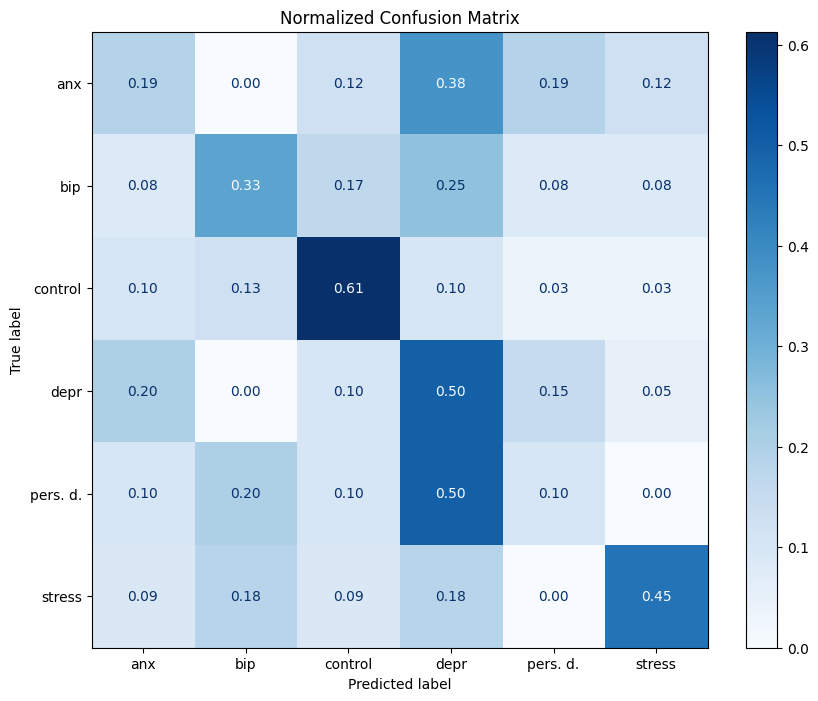

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                              display_labels=['anx', 'bip', 'control', 'depr', 'pers. d.', 'stress'])

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')

ax.set_title('Normalized Confusion Matrix')
plt.show()

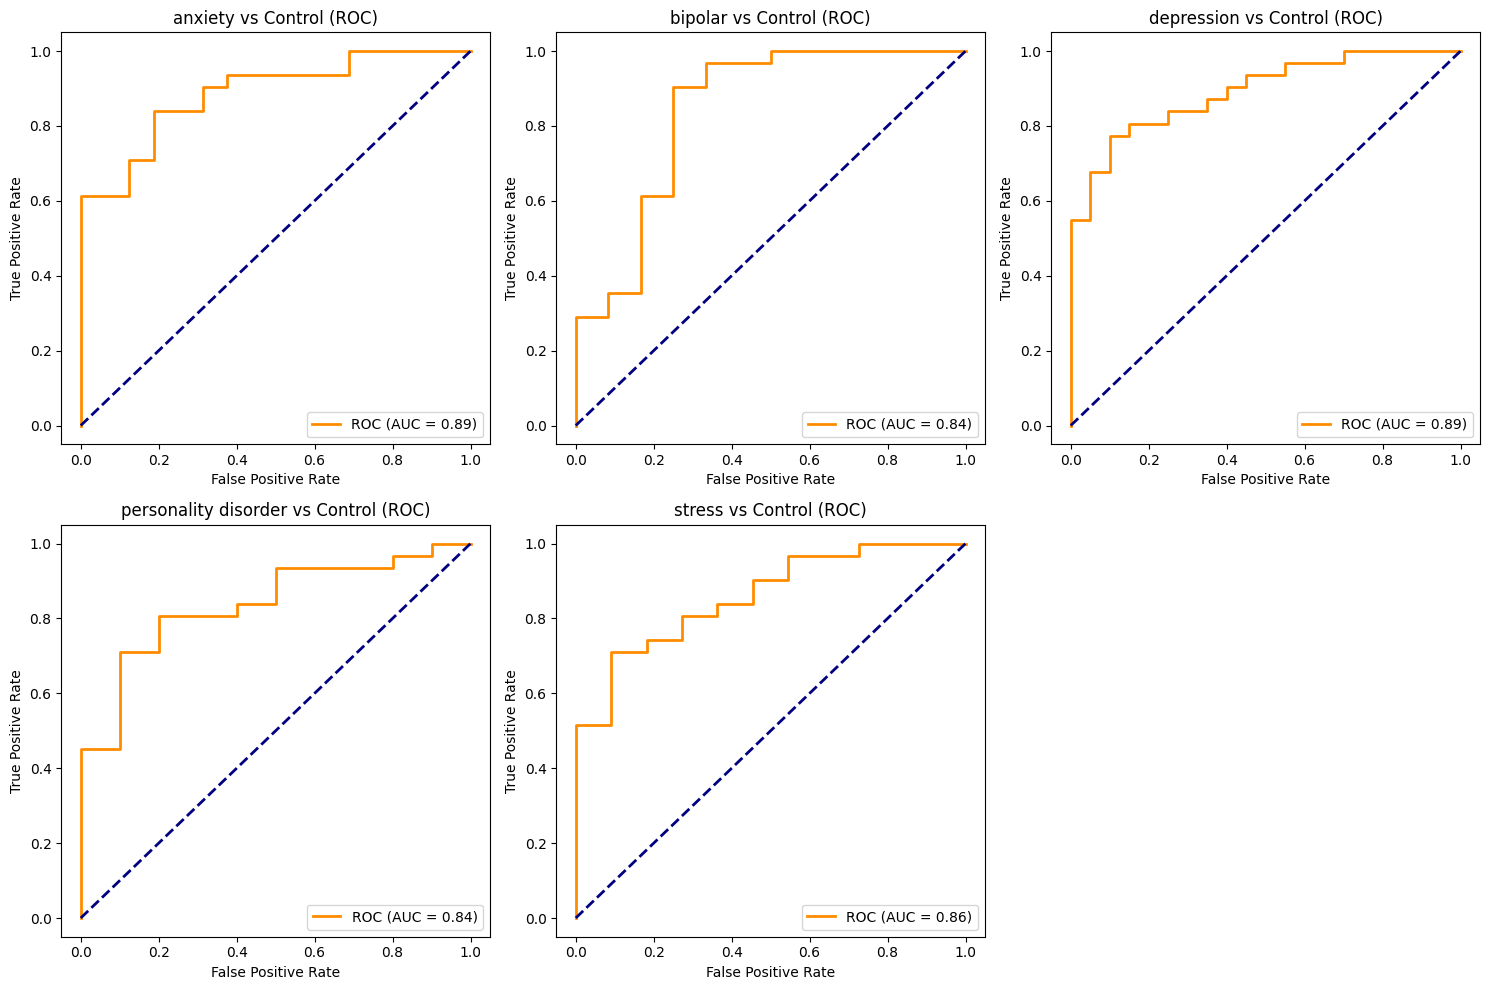

ROC AUC Scores: {0: np.float64(0.8870967741935484), 1: np.float64(0.8413978494623656), 3: np.float64(0.8919354838709677), 4: np.float64(0.8387096774193549), 5: np.float64(0.8592375366568915)}
PR AUC Scores: {0: np.float64(0.9449136460239508), 1: np.float64(0.9188706612465831), 3: np.float64(0.9371372504366009), 4: np.float64(0.9461050550637945), 5: np.float64(0.9491188746847747)}


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Define classes (assuming 'control' is index 2)
pathologies = [0, 1, 3, 4, 5]
control_class = 2

# Store results
roc_aucs = {}
pr_aucs = {}

# Initialize plots
plt.figure(figsize=(15, 10))

# --- Loop through each pathology ---
for i, pathology in enumerate(pathologies):
    # 1. Filter data (only pathology + control)
    pathology_mask = (y_test == pathology) | (y_test == control_class)
    X_test_subset = X_test[pathology_mask]
    y_test_subset = y_test[pathology_mask]
    
    # 2. Binarize labels (1 for pathology, 0 for control)
    y_test_binary = (y_test_subset == control_class).astype(int)
    
    # 3. Predict probabilities for the pathology class
    # (Note: `clf.classes_` must match the order in predict_proba)
    proba_pathology = clf.predict_proba(X_test_subset)[:, clf.classes_.tolist().index(control_class)]
    
    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test_binary, proba_pathology)
    roc_auc = auc(fpr, tpr)
    roc_aucs[pathology] = roc_auc
    
    # --- PR Curve ---
    precision, recall, _ = precision_recall_curve(y_test_binary, proba_pathology)
    pr_auc = average_precision_score(y_test_binary, proba_pathology)
    pr_aucs[pathology] = pr_auc
    
    # --- Plotting ---
    # ROC
    plt.subplot(2, 3, i+1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{class2name[pathology]} vs Control (ROC)')
    plt.legend(loc='lower right')
    
    # # PR
    # plt.subplot(2, 3, i+2)
    # plt.plot(recall, precision, color='blue', lw=2, label=f'PR (AP = {pr_auc:.2f})')
    # plt.xlabel('Recall')
    # plt.ylabel('Precision')
    # plt.title(f'{class2name[pathology]} vs Control (PR)')
    # plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print AUC scores
print("ROC AUC Scores:", roc_aucs)
print("PR AUC Scores:", pr_aucs)

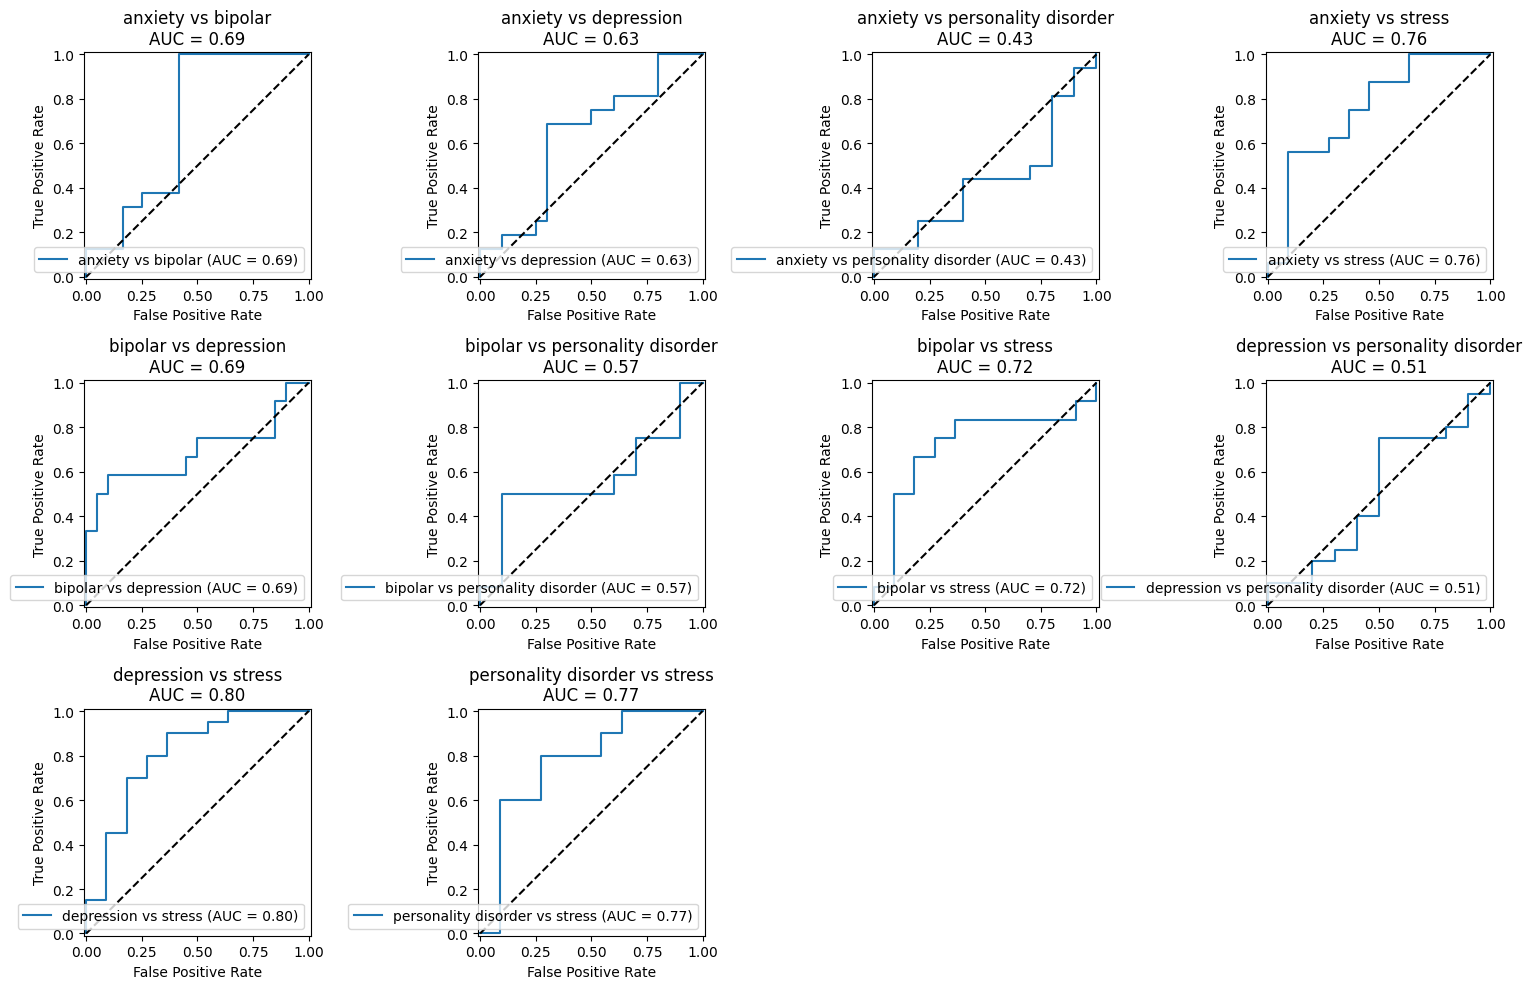

In [41]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define all pathology classes (excluding 'control')
pathologies = [0, 1, 3, 4, 5]

# Generate all possible pairs of pathologies
pathology_pairs = list(combinations(pathologies, 2))

# Initialize figure
plt.figure(figsize=(15, 10))

# Loop through each pathology pair
for i, (class1, class2) in enumerate(pathology_pairs):
    # 1. Filter data (only the two pathologies in the pair)
    mask = (y_test == class1) | (y_test == class2)
    X_pair = X_test[mask]
    y_pair = y_test[mask]
    
    # 2. Binarize labels (1 for class1, 0 for class2)
    y_binary = (y_pair == class1).astype(int)
    
    # 3. Get predicted probabilities for class1
    probs = clf.predict_proba(X_pair)
    proba_class1 = probs[:, clf.classes_.tolist().index(class1)]
    proba_class2 = probs[:, clf.classes_.tolist().index(class2)]
    normed_probs = proba_class1 / (proba_class1 + proba_class2)
    
    # 4. Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_binary, normed_probs)
    roc_auc = auc(fpr, tpr)
    
    # 5. Plot ROC curve
    plt.subplot(3, 4, i+1)  # Adjust subplot grid as needed
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f'{class2name[class1]} vs {class2name[class2]}').plot(ax=plt.gca())
    plt.title(f'{class2name[class1]} vs {class2name[class2]}\nAUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing

plt.tight_layout()
plt.show()